# GBD paper

## Reconstruct tables as preprint

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

True

In [3]:
DATA_FOLDER = os.getenv('DATA_FOLDER', 'data')  # Default to 'data' if not set
df = pd.read_csv(os.path.join(DATA_FOLDER, 'sbod_data.csv'))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [4]:
df.nunique()

Year                 6
Cause               71
Location            18
Age                  7
Sex                  3
RAG                  1
Measure          28045
Value                2
Small numbers        4
dtype: int64

In [5]:
sorted(df["Location"].unique().tolist())

['East',
 'NHS Ayrshire and Arran',
 'NHS Borders',
 'NHS Dumfries and Galloway',
 'NHS Fife',
 'NHS Forth Valley',
 'NHS Grampian',
 'NHS Greater Glasgow and Clyde',
 'NHS Highland',
 'NHS Lanarkshire',
 'NHS Lothian',
 'NHS Orkney',
 'NHS Shetland',
 'NHS Tayside',
 'NHS Western Isles',
 'North',
 'Scotland',
 'West']

In [6]:
for dir in ["North", "East", "West"]:
    mask = df["Location"].str.contains(dir)
    df.loc[mask, "Location"] = f"{dir} Scotland"

We focus only on Grampian region first and then extend to other locations.

In [7]:
location = "NHS Grampian"

In [8]:
# We're looking only at the DALY rate for now, so let's filter the data accordingly.
df1 = df[df["RAG"] == "DALY rate"]

# Remove only the "All causes" row, which is not relevant to our analysis
df1 = df1[df1["Cause"] != "All causes of disease and injury"]

# Let's filter out the required locations
df1 = df1[df1["Location"].isin([location, "Scotland"])]

df1.info()

<class 'pandas.DataFrame'>
Index: 17640 entries, 18 to 159110
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Year           17640 non-null  int64
 1   Cause          17640 non-null  str  
 2   Location       17640 non-null  str  
 3   Age            17640 non-null  str  
 4   Sex            17640 non-null  str  
 5   RAG            17640 non-null  str  
 6   Measure        17640 non-null  str  
 7   Value          17640 non-null  str  
 8   Small numbers  17640 non-null  str  
dtypes: int64(1), str(8)
memory usage: 1.3 MB


In [9]:
df1.nunique()

Year                6
Cause              70
Location            2
Age                 7
Sex                 3
RAG                 1
Measure          7814
Value               2
Small numbers       3
dtype: int64

In [10]:
cols_to_drop = ["RAG", "Value", "Small numbers"]
df1 = df1.drop(columns=cols_to_drop)
df1 = df1.rename(columns={"Measure": "DALY rate"})
df1.info()

<class 'pandas.DataFrame'>
Index: 17640 entries, 18 to 159110
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       17640 non-null  int64
 1   Cause      17640 non-null  str  
 2   Location   17640 non-null  str  
 3   Age        17640 non-null  str  
 4   Sex        17640 non-null  str  
 5   DALY rate  17640 non-null  str  
dtypes: int64(1), str(5)
memory usage: 964.7 KB


In [11]:
df1["Age"].unique().tolist()

['Under 15',
 '15 to 24',
 '25 to 44',
 '45 to 64',
 '65 to 84',
 '85 and over',
 'All ages']

In [12]:
df1[(df1["Year"] == 2019) & (df1["Cause"] == "Alzheimer's disease and other dementias") & (df1["Sex"] == "Female")]

,Year,Cause,Location,Age,Sex,DALY rate
115728,2019,Alzheimer's disease and other dementias,Scotland,Under 15,Female,22.4
115729,2019,Alzheimer's disease and other dementias,Scotland,15 to 24,Female,0.0
115730,2019,Alzheimer's disease and other dementias,Scotland,25 to 44,Female,2.3
115731,2019,Alzheimer's disease and other dementias,Scotland,45 to 64,Female,130.1
115732,2019,Alzheimer's disease and other dementias,Scotland,65 to 84,Female,"5,154.6"
115733,2019,Alzheimer's disease and other dementias,Scotland,85 and over,Female,"36,474.9"
125952,2019,Alzheimer's disease and other dementias,NHS Grampian,Under 15,Female,0.0
125953,2019,Alzheimer's disease and other dementias,NHS Grampian,15 to 24,Female,0.0
125954,2019,Alzheimer's disease and other dementias,NHS Grampian,25 to 44,Female,2.0
125955,2019,Alzheimer's disease and other dementias,NHS Grampian,45 to 64,Female,71.5


In [13]:
daly_df = df1[df1["Age"] == "All ages"].drop(columns=["Age"])
daly_df.info()

<class 'pandas.DataFrame'>
Index: 2520 entries, 138027 to 159110
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       2520 non-null   int64
 1   Cause      2520 non-null   str  
 2   Location   2520 non-null   str  
 3   Sex        2520 non-null   str  
 4   DALY rate  2520 non-null   str  
dtypes: int64(1), str(4)
memory usage: 118.1 KB


In [14]:
daly_df[daly_df["Cause"] == "Alzheimer's disease and other dementias"]

,Year,Cause,Location,Sex,DALY rate
138141,2014,Alzheimer's disease and other dementias,Scotland,Male,"1,424.3"
138142,2014,Alzheimer's disease and other dementias,Scotland,Female,"1,631.0"
138143,2014,Alzheimer's disease and other dementias,Scotland,Both sexes,"1,563.0"
139845,2014,Alzheimer's disease and other dementias,NHS Grampian,Male,"1,504.3"
139846,2014,Alzheimer's disease and other dementias,NHS Grampian,Female,"1,472.2"
139847,2014,Alzheimer's disease and other dementias,NHS Grampian,Both sexes,"1,503.1"
141975,2015,Alzheimer's disease and other dementias,Scotland,Male,"1,605.4"
141976,2015,Alzheimer's disease and other dementias,Scotland,Female,"1,824.4"
141977,2015,Alzheimer's disease and other dementias,Scotland,Both sexes,"1,757.4"
143679,2015,Alzheimer's disease and other dementias,NHS Grampian,Male,"1,597.8"


In [15]:
daly_df["location_yr"] = daly_df["Location"] + "_" + daly_df["Year"].astype(str)
daly_df["daly_int"] = (
    pd.to_numeric(
        daly_df["DALY rate"].astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )
    .round()
    .astype("Int64")
)
tables = {}
for gender in daly_df["Sex"].unique():
    # Filter the data for the current gender
    filtered_df = daly_df[daly_df["Sex"] == gender]
    
    # Pivot the data to have causes as columns and location-year combinations as rows
    pivoted_df = pd.pivot_table(
        filtered_df,
        index='Cause',
        columns='location_yr',
        values='daly_int',
        aggfunc='first' # Use 'sum' or 'mean' if you have duplicate rows for the same condition/location/year
    ).reset_index()

    # Clean up the axis label (removes the 'location_year' label floating above the columns)
    pivoted_df.columns.name = None
    
    # Save the table in our dictionary
    tables[gender] = pivoted_df

In [16]:
cols = ["Cause", "Scotland_2019", f"{location}_2014", f"{location}_2015", f"{location}_2016", f"{location}_2017", f"{location}_2018", f"{location}_2019"]
m_df = tables["Male"][cols]
f_df = tables["Female"][cols]
# b_df = tables["Both sexes"][cols]

We sort them by Scotland's value and retain the top 25 causes in location according to 2019 value.

In [17]:
f_df[f"{location}_diff"] = f_df["Scotland_2019"] - f_df[f"{location}_2019"]
f_df = f_df.sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True)
f_df.head()

,Cause,Scotland_2019,NHS Grampian_2014,NHS Grampian_2015,NHS Grampian_2016,NHS Grampian_2017,NHS Grampian_2018,NHS Grampian_2019,NHS Grampian_diff
0,Alzheimer's disease and other dementias,1827,1472,1636,1616,1655,1675,1693,134
1,Ischaemic heart disease,1605,1543,1402,1525,1639,1635,1489,116
2,Lung cancer,1474,1355,1337,1163,1110,1287,1366,108
3,Low back and neck pain,1452,1370,1370,1370,1391,1391,1390,62
4,Cerebrovascular disease,1379,1488,1510,1508,1521,1391,1414,-35


In [18]:
m_df[f"{location}_diff"] = m_df["Scotland_2019"] - m_df[f"{location}_2019"]
m_df = m_df.sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True)
m_df.head()

,Cause,Scotland_2019,NHS Grampian_2014,NHS Grampian_2015,NHS Grampian_2016,NHS Grampian_2017,NHS Grampian_2018,NHS Grampian_2019,NHS Grampian_diff
0,Ischaemic heart disease,3713,3909,3353,3311,3495,3422,3488,225
1,Drug use disorders,2367,889,887,1007,1337,1308,1233,1134
2,Lung cancer,1749,1731,1656,1842,1737,1738,1605,144
3,Alzheimer's disease and other dementias,1639,1504,1598,1370,1536,1578,1592,47
4,Cerebrovascular disease,1516,1629,1776,1800,1720,1763,1291,225


In [19]:
m_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_males_2014_2019.csv"), index=False)
f_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_females_2014_2019.csv"), index=False)
# b_df.to_csv("both_sexes_2014_2019.csv", index=False)

In [20]:
def get_cagr(row, loc, base_yr, final_yr=2019):
    base_value = row[f"{loc}_{base_yr}"]
    final_value = row[f"{loc}_{final_yr}"]
    if base_value == 0:
        return 0
    cagr = 100*((final_value / base_value) ** (1 / (final_yr - base_yr)) - 1)
    return round(cagr,2)

In [21]:
threshold = 1

In [22]:
f_df[f"{location}_CAGR_2014"] = f_df.apply(lambda row: get_cagr(row, location, 2014), axis=1)
f_df[f"{location}_CAGR_2017"] = f_df.apply(lambda row: get_cagr(row, location, 2017), axis=1)
f_df[f"{location}_inclusion_change"] = f_df.apply(lambda row: "Yes" if (threshold - row[f"{location}_CAGR_2014"])*(1 - row[f"{location}_CAGR_2017"]) < 0 else "No", axis=1)

In [23]:
m_df[f"{location}_CAGR_2014"] = m_df.apply(lambda row: get_cagr(row, location, 2014), axis=1)
m_df[f"{location}_CAGR_2017"] = m_df.apply(lambda row: get_cagr(row, location, 2017), axis=1)
m_df[f"{location}_inclusion_change"] = m_df.apply(lambda row: "Yes" if (threshold - row[f"{location}_CAGR_2014"])*(1 - row[f"{location}_CAGR_2017"]) < 0 else "No", axis=1)

In [24]:
# b_df[f"{location}_CAGR_2014"] = b_df.apply(lambda row: get_cagr(row, location, 2014), axis=1)
# b_df[f"{location}_CAGR_2016"] = b_df.apply(lambda row: get_cagr(row, location, 2016), axis=1)
# b_df[f"{location}_inclusion_change"] = b_df.apply(lambda row: "Yes" if (threshold - row[f"{location}_CAGR_2014"])*(1 - row[f"{location}_CAGR_2016"]) < 0 else "No", axis=1)

In [25]:
m_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_males_2014_2019.csv"), index=False)
f_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_females_2014_2019.csv"), index=False)
# b_df.to_csv("both_sexes_2014_2019.csv", index=False)

## Plots

First we show why CAGR is not a good metric for measuring growth

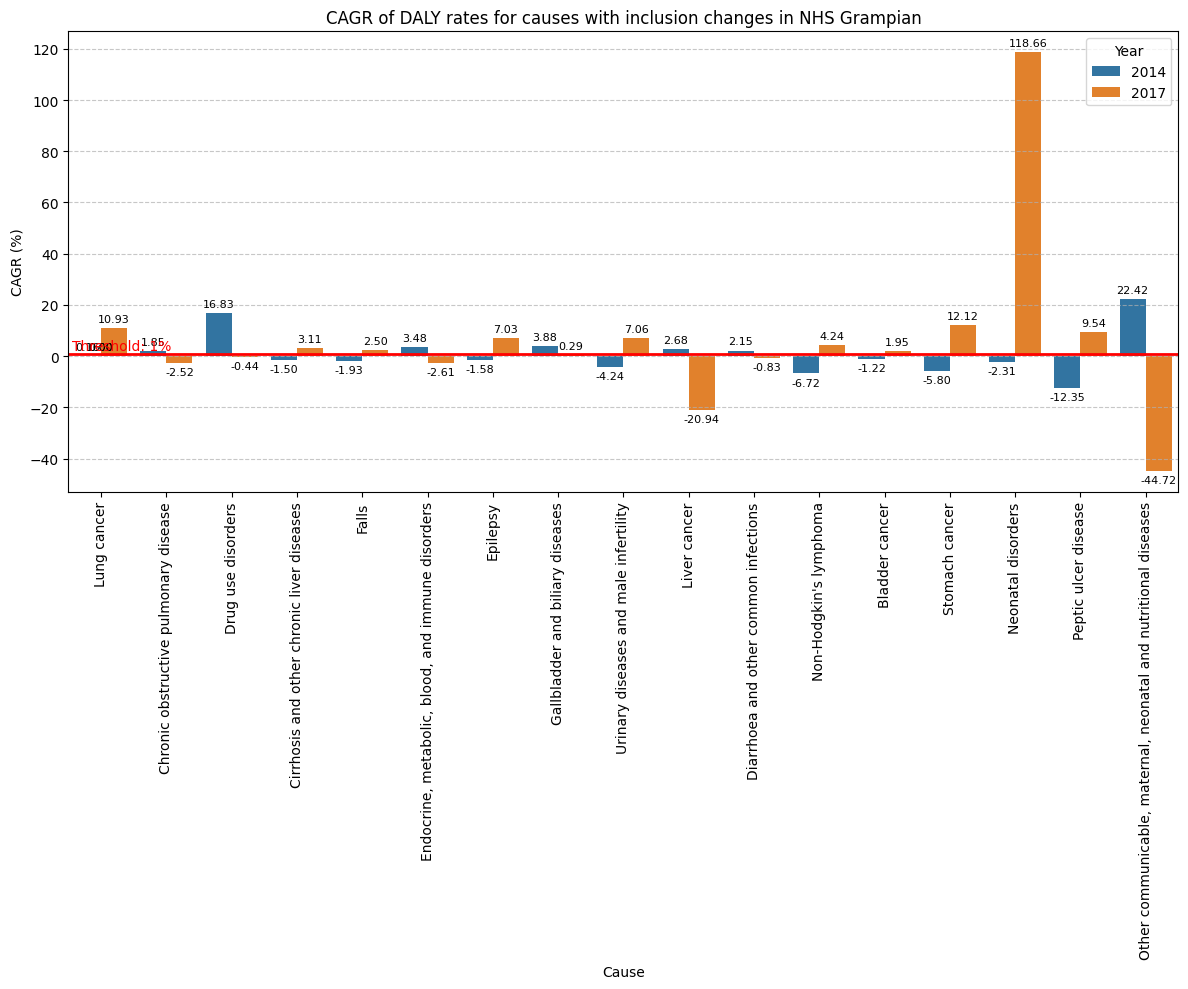

In [26]:
plot_df = f_df[f_df[f"{location}_inclusion_change"] == "Yes"][["Cause", f"{location}_CAGR_2014", f"{location}_CAGR_2017"]]
plot_df = plot_df.melt(id_vars="Cause", var_name="Year", value_name="CAGR")
plot_df["Year"] = plot_df["Year"].str.replace(f"{location}_CAGR_", "")

plt.figure(figsize=(12, 10))
ax = sns.barplot(data=plot_df, x="Cause", y="CAGR", hue="Year")

# annotate each bar
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h:.2f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom" if h >= 0 else "top",
        xytext=(0, 3 if h >= 0 else -3),
        textcoords="offset points",
        fontsize=8
    )

plt.xticks(rotation=90)
plt.axhline(threshold, color="red", linestyle="-", linewidth=2)
plt.text(-0.45, threshold + 0.2, f"Threshold: {threshold}%", color="red", fontsize=10, ha="left", va="bottom")
plt.title(f"CAGR of DALY rates for causes with inclusion changes in {location}")
plt.xlabel("Cause")
plt.ylabel("CAGR (%)")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
f_df.shape, m_df.shape

((70, 12), (70, 12))

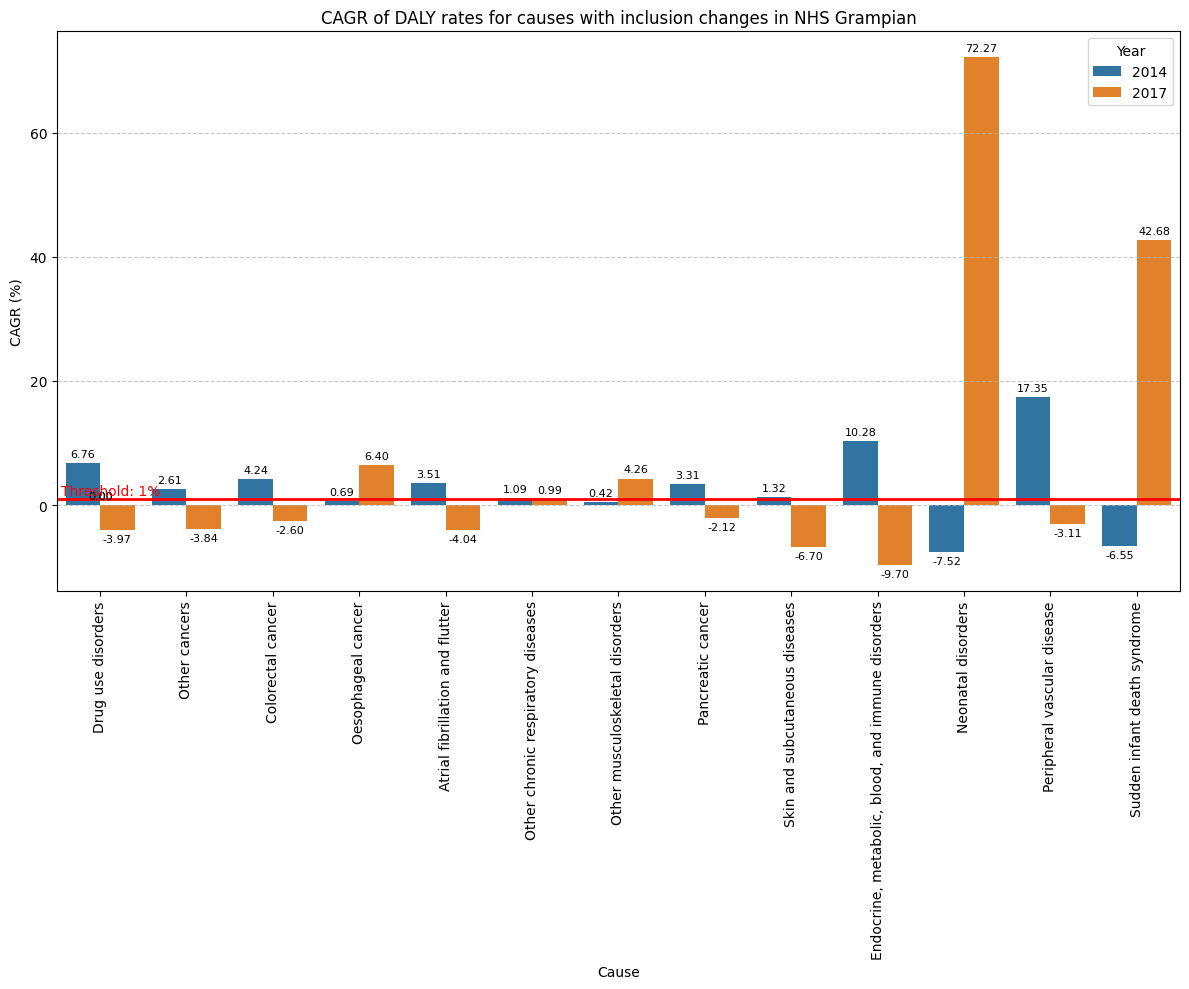

In [28]:
plot_df = m_df[m_df[f"{location}_inclusion_change"] == "Yes"][["Cause", f"{location}_CAGR_2014", f"{location}_CAGR_2017"]]
plot_df = plot_df.melt(id_vars="Cause", var_name="Year", value_name="CAGR")
plot_df["Year"] = plot_df["Year"].str.replace(f"{location}_CAGR_", "")

plt.figure(figsize=(12, 10))
ax = sns.barplot(data=plot_df, x="Cause", y="CAGR", hue="Year")

# annotate each bar
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h:.2f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom" if h >= 0 else "top",
        xytext=(0, 3 if h >= 0 else -3),
        textcoords="offset points",
        fontsize=8
    )

plt.xticks(rotation=90)
plt.axhline(threshold, color="red", linestyle="-", linewidth=2)
plt.text(-0.45, threshold + 0.2, f"Threshold: {threshold}%", color="red", fontsize=10, ha="left", va="bottom")
plt.title(f"CAGR of DALY rates for causes with inclusion changes in {location}")
plt.xlabel("Cause")
plt.ylabel("CAGR (%)")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Thiel-Sen Quotient

In [29]:
import math

def get_pos(N, percentile=50):
    val = (percentile / 100) * (N - 1) # This gives us the position in a 0-indexed list
    return math.floor(val), val

In [30]:
N = 15
get_pos(N, 75)

(10, 10.5)

In [31]:
def get_tsq(x, y=None, q=2, norm_mode="mean"):
    # Supports:
    # 1) get_tsq({year: value, ...}, q=2)
    # 2) get_tsq([years...], [values...], q=2)
    if y is None:
        if not isinstance(x, dict):
            raise ValueError("If 'y' is None, 'x' must be a dict of {x: y}.")
        x_arr = np.asarray(list(x.keys()), dtype=float)
        y_arr = np.asarray(list(x.values()), dtype=float)
    else:
        x_arr = np.asarray(x, dtype=float)
        y_arr = np.asarray(y, dtype=float)

    n = x_arr.size
    if n < 2:
        return 0.0

    # All pairwise slopes for i < j (vectorized)
    i, j = np.triu_indices(n, k=1)
    dx = x_arr[j] - x_arr[i]
    dy = y_arr[j] - y_arr[i]
    slopes = dy / dx  # dx != 0 for years

    # Percentile selection
    percentile = 50 if q == 2 else 75 if q == 3 else 50
    order = np.argsort(slopes)
    slopes_sorted = slopes[order]
    i_sorted = i[order]
    j_sorted = j[order]

    m = slopes_sorted.size
    ts_index, weight_val = get_pos(m, percentile)
    frac = weight_val - ts_index

    if ts_index >= m - 1:
        ts_slope = slopes_sorted[-1]
        frac = 0.0
    else:
        ts_slope = slopes_sorted[ts_index] + frac * (slopes_sorted[ts_index + 1] - slopes_sorted[ts_index])

    # Normalization constant
    if norm_mode == "mean":
        norm_const = y_arr.mean()
    elif norm_mode == "median":
        norm_const = np.median(y_arr)
    elif norm_mode == "interval":
        if frac == 0.0 or ts_index >= m - 1:
            yrs_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            yrs_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[yrs_idx].mean()
    elif norm_mode == "base":
        if frac == 0.0 or ts_index >= m - 1:
            yrs_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            yrs_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[yrs_idx].min()
    else:
        raise ValueError("norm_mode must be one of: 'mean', 'median', 'interval'")

    return round(100 * ts_slope / norm_const, 2) if norm_const != 0 else 0.0

In [32]:
norm_modes = ["mean", "median", "interval", "base"]

for norm_mode in norm_modes:
    f_df[f"{location}_tsq2_{norm_mode}"] = f_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=2, norm_mode=norm_mode), axis=1)
for norm_mode in norm_modes:
    f_df[f"{location}_tsq3_{norm_mode}"] = f_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=3, norm_mode=norm_mode), axis=1)
f_df.head()

,Cause,Scotland_2019,NHS Grampian_2014,NHS Grampian_2015,NHS Grampian_2016,NHS Grampian_2017,NHS Grampian_2018,NHS Grampian_2019,NHS Grampian_diff,NHS Grampian_CAGR_2014,NHS Grampian_CAGR_2017,NHS Grampian_inclusion_change,NHS Grampian_tsq2_mean,NHS Grampian_tsq2_median,NHS Grampian_tsq2_interval,NHS Grampian_tsq2_base,NHS Grampian_tsq3_mean,NHS Grampian_tsq3_median,NHS Grampian_tsq3_interval,NHS Grampian_tsq3_base
0,Alzheimer's disease and other dementias,1827,1472,1636,1616,1655,1675,1693,134,2.84,1.14,No,1.58,1.56,1.55,1.59,2.92,2.89,2.94,3.23
1,Ischaemic heart disease,1605,1543,1402,1525,1639,1635,1489,116,-0.71,-4.69,No,1.41,1.42,1.50,1.55,4.31,4.32,4.36,4.73
2,Lung cancer,1474,1355,1337,1163,1110,1287,1366,108,0.16,10.93,Yes,-1.31,-1.27,-1.27,-1.30,5.11,4.94,5.10,5.57
3,Low back and neck pain,1452,1370,1370,1370,1391,1391,1390,62,0.29,-0.04,No,0.36,0.36,0.36,0.36,0.51,0.51,0.51,0.51
4,Cerebrovascular disease,1379,1488,1510,1508,1521,1391,1414,-35,-1.02,-3.58,No,-1.01,-0.99,-1.02,-1.05,0.71,0.70,0.70,0.71


In [33]:
for norm_mode in norm_modes:
    m_df[f"{location}_tsq2_{norm_mode}"] = m_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=2, norm_mode=norm_mode), axis=1)
for norm_mode in norm_modes:
    m_df[f"{location}_tsq3_{norm_mode}"] = m_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=3, norm_mode=norm_mode), axis=1)
m_df.head()

,Cause,Scotland_2019,NHS Grampian_2014,NHS Grampian_2015,NHS Grampian_2016,NHS Grampian_2017,NHS Grampian_2018,NHS Grampian_2019,NHS Grampian_diff,NHS Grampian_CAGR_2014,NHS Grampian_CAGR_2017,NHS Grampian_inclusion_change,NHS Grampian_tsq2_mean,NHS Grampian_tsq2_median,NHS Grampian_tsq2_interval,NHS Grampian_tsq2_base,NHS Grampian_tsq3_mean,NHS Grampian_tsq3_median,NHS Grampian_tsq3_interval,NHS Grampian_tsq3_base
0,Ischaemic heart disease,3713,3909,3353,3311,3495,3422,3488,225,-2.25,-0.10,No,-0.10,-0.10,-0.10,-0.10,1.64,1.66,1.68,1.73
1,Drug use disorders,2367,889,887,1007,1337,1308,1233,1134,6.76,-3.97,Yes,7.79,7.72,8.16,9.75,13.05,12.93,13.10,16.33
2,Lung cancer,1749,1731,1656,1842,1737,1738,1605,144,-1.50,-3.87,No,-0.74,-0.74,-0.78,-0.79,0.85,0.85,0.85,0.89
3,Alzheimer's disease and other dementias,1639,1504,1598,1370,1536,1578,1592,47,1.14,1.81,No,1.15,1.13,1.14,1.17,3.79,3.73,3.82,4.23
4,Cerebrovascular disease,1516,1629,1776,1800,1720,1763,1291,225,-4.54,-13.36,No,-1.11,-1.06,-1.04,-1.05,1.92,1.83,1.87,1.96


In [34]:
# for norm_mode in norm_modes:
#     b_df[f"{location}_tsq2_{norm_mode}"] = b_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=2, norm_mode=norm_mode), axis=1)
#     b_df[f"{location}_tsq3_{norm_mode}"] = b_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=3, norm_mode=norm_mode), axis=1)
# b_df.head()

In [35]:
set(f_df.columns) == set(m_df.columns)

True

In [36]:
f_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cause                          70 non-null     str    
 1   Scotland_2019                  70 non-null     Int64  
 2   NHS Grampian_2014              70 non-null     Int64  
 3   NHS Grampian_2015              70 non-null     Int64  
 4   NHS Grampian_2016              70 non-null     Int64  
 5   NHS Grampian_2017              70 non-null     Int64  
 6   NHS Grampian_2018              70 non-null     Int64  
 7   NHS Grampian_2019              70 non-null     Int64  
 8   NHS Grampian_diff              70 non-null     Int64  
 9   NHS Grampian_CAGR_2014         70 non-null     float64
 10  NHS Grampian_CAGR_2017         70 non-null     float64
 11  NHS Grampian_inclusion_change  70 non-null     str    
 12  NHS Grampian_tsq2_mean         70 non-null     float64
 13  NHS

In [37]:
m_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_males_2014_2019.csv"), index=False)
f_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_females_2014_2019.csv"), index=False)
# b_df.to_csv(os.path.join("data", f"{location.lower().replace(" ", "_")}_both_sexes_2014_2019.csv"), index=False)

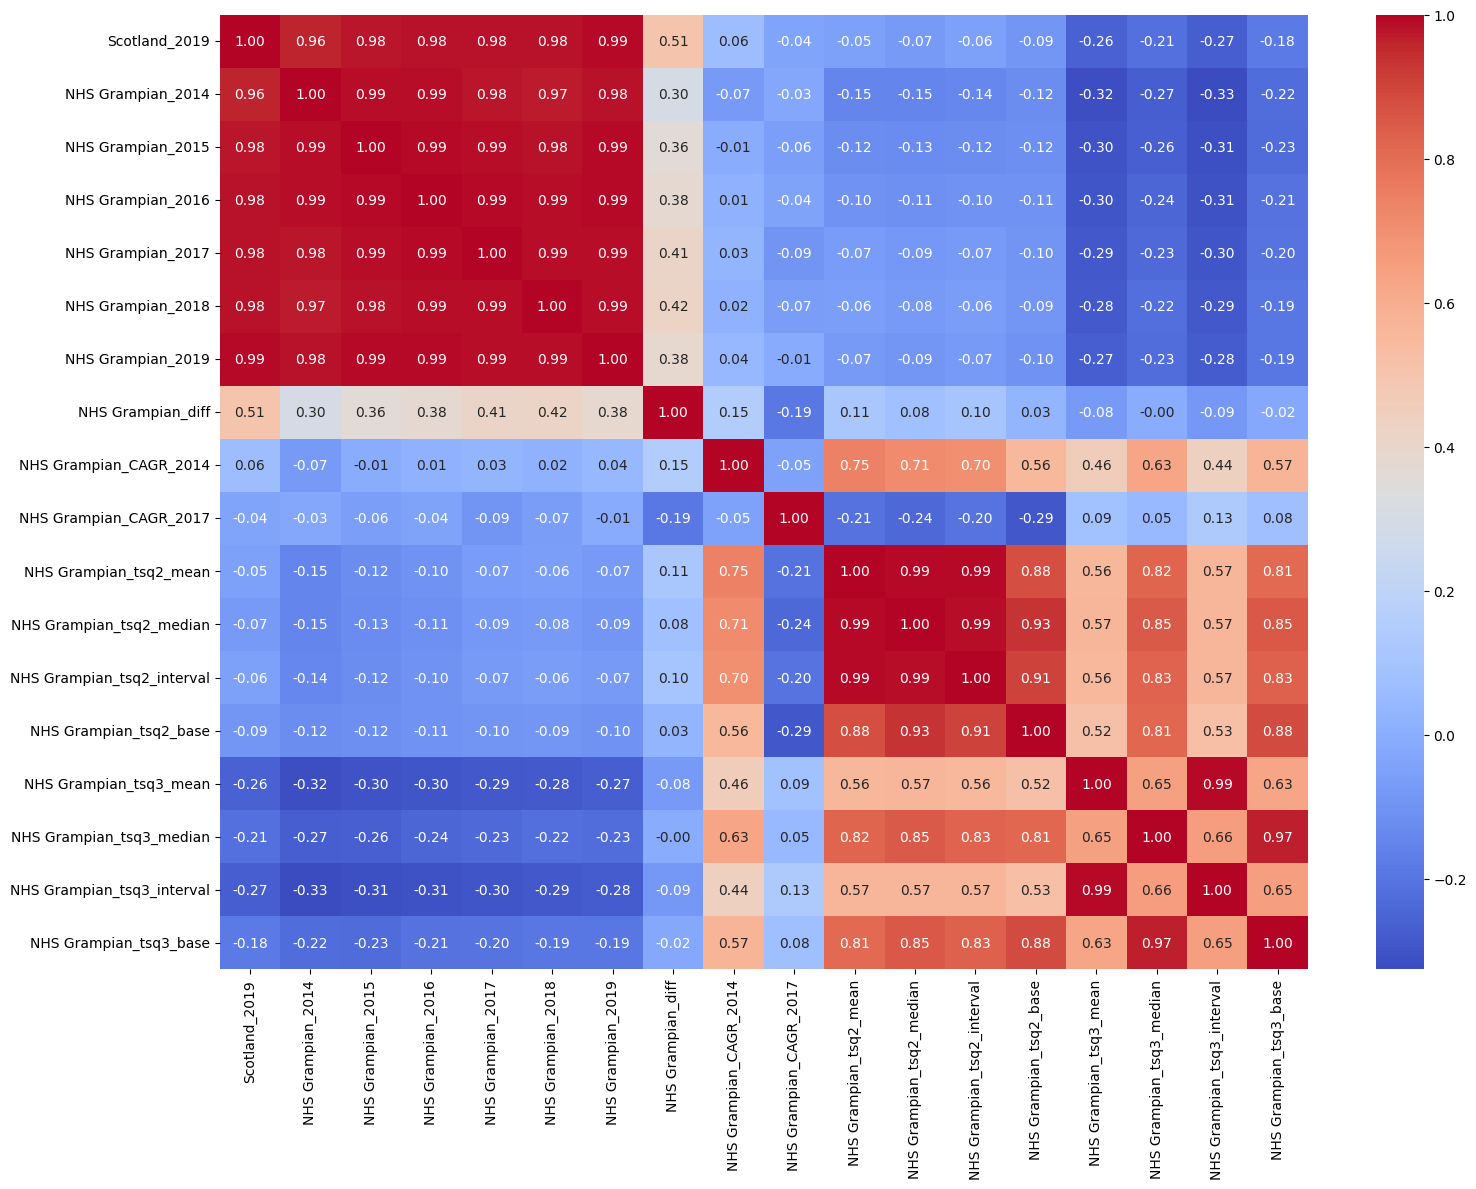

In [38]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    f_df.drop(columns=["Cause", f"{location}_inclusion_change"]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

### Table 2

In [39]:
f_df.columns

Index(['Cause', 'Scotland_2019', 'NHS Grampian_2014', 'NHS Grampian_2015',
       'NHS Grampian_2016', 'NHS Grampian_2017', 'NHS Grampian_2018',
       'NHS Grampian_2019', 'NHS Grampian_diff', 'NHS Grampian_CAGR_2014',
       'NHS Grampian_CAGR_2017', 'NHS Grampian_inclusion_change',
       'NHS Grampian_tsq2_mean', 'NHS Grampian_tsq2_median',
       'NHS Grampian_tsq2_interval', 'NHS Grampian_tsq2_base',
       'NHS Grampian_tsq3_mean', 'NHS Grampian_tsq3_median',
       'NHS Grampian_tsq3_interval', 'NHS Grampian_tsq3_base'],
      dtype='str')

In [40]:
diseases_f = list(set(f_df[(f_df[f"{location}_CAGR_2014"] > threshold)]["Cause"].values.tolist()).union(set(f_df.iloc[:3]["Cause"].values.tolist())))
tab2_df = df1[(df1["Sex"] == "Female") & (df1["Cause"].isin(diseases_f))]
tab2_df.info()

<class 'pandas.DataFrame'>
Index: 1680 entries, 24 to 159094
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       1680 non-null   int64
 1   Cause      1680 non-null   str  
 2   Location   1680 non-null   str  
 3   Age        1680 non-null   str  
 4   Sex        1680 non-null   str  
 5   DALY rate  1680 non-null   str  
dtypes: int64(1), str(5)
memory usage: 91.9 KB


In [41]:
tab2_df[(tab2_df["Year"]==2019) & (tab2_df["Location"] == location) & (tab2_df["Cause"] == "Breast cancer")]

,Year,Cause,Location,Age,Sex,DALY rate


In [42]:
tab2 = pd.pivot_table(tab2_df[(tab2_df["Year"]==2019) & (tab2_df["Location"] == location)], index="Cause", columns=["Age"], values="DALY rate", aggfunc="first").reset_index()
tab2.columns.name = None
cols = ["Cause", "All ages", "Under 15", "15 to 24", "25 to 44", "45 to 64", "65 to 84", "85 and over"]
tab2 = tab2[cols].sort_values(by="All ages", ascending=False).reset_index(drop=True)

for col in cols[1:]:
    tab2[col] = tab2[col].apply(lambda x: round(float(str(x).replace(",", ""))) if pd.notnull(x) else x)

tab2

,Cause,All ages,Under 15,15 to 24,25 to 44,45 to 64,65 to 84,85 and over
0,Alzheimer's disease and other dementias,1693,0,0,2,72,4489,36399
1,Ischaemic heart disease,1489,0,1,81,1012,4929,14448
2,Lung cancer,1366,0,0,73,1765,4778,2660
3,Chronic obstructive pulmonary disease,1087,0,15,133,865,4143,4646
4,Colorectal cancer,726,5,7,383,530,2271,3851
5,Drug use disorders,677,0,430,1763,561,65,8
6,Self-harm and interpersonal violence,332,1,1039,381,365,68,118
7,"Endocrine, metabolic, blood, and immune disorders",331,28,35,135,494,689,1551
8,Pancreatic cancer,324,0,0,0,270,1291,1322
9,Atrial fibrillation and flutter,319,0,1,6,47,1057,4997


In [ ]:
tab2.to_excel(f"{location}_tab2.xlsx", index=False)

### Table 4

In [43]:
diseases_m = list(set(m_df[(m_df[f"{location}_CAGR_2014"] > threshold)]["Cause"].values.tolist()).union(set(m_df.iloc[:3]["Cause"].values.tolist())))
tab4_df = df1[(df1["Sex"] == "Male") & (df1["Cause"].isin(diseases_m))]
tab4_df.info()

<class 'pandas.DataFrame'>
Index: 2688 entries, 54 to 159108
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       2688 non-null   int64
 1   Cause      2688 non-null   str  
 2   Location   2688 non-null   str  
 3   Age        2688 non-null   str  
 4   Sex        2688 non-null   str  
 5   DALY rate  2688 non-null   str  
dtypes: int64(1), str(5)
memory usage: 147.0 KB


In [ ]:
diseases_m

In [44]:
tab4 = pd.pivot_table(tab4_df[(tab4_df["Year"]==2019) & (tab4_df["Location"] == location)], index="Cause", columns=["Age"], values="DALY rate", aggfunc="first").reset_index()
tab4.columns.name = None
cols = ["Cause", "All ages", "Under 15", "15 to 24", "25 to 44", "45 to 64", "65 to 84", "85 and over"]
tab4 = tab4[cols].sort_values(by="All ages", ascending=False).reset_index(drop=True)

for col in cols[1:]:
    tab4[col] = tab4[col].apply(lambda x: round(float(str(x).replace(",", ""))) if pd.notnull(x) else x)

tab4

,Cause,All ages,Under 15,15 to 24,25 to 44,45 to 64,65 to 84,85 and over
0,Ischaemic heart disease,3488,1,2,391,3577,11196,21317
1,Lung cancer,1605,0,0,141,1574,5874,6083
2,Alzheimer's disease and other dementias,1592,0,0,1,204,4632,29994
3,Drug use disorders,1233,0,884,2671,1564,21,193
4,Other cancers,1142,174,248,364,1349,3209,3429
5,Diabetes mellitus,973,19,62,286,1266,2802,3015
6,Colorectal cancer,960,6,11,94,872,3327,5437
7,Self-harm and interpersonal violence,934,2,1161,1690,970,442,796
8,Atrial fibrillation and flutter,454,0,3,20,229,1601,4630
9,Other digestive diseases,368,17,14,104,142,1287,3207


In [ ]:
tab4.to_excel(f"{location}_tab4.xlsx", index=False)